# Street Food Image Classification with CNN

<img src='https://www.tilda.com/wp-content/uploads/2024/07/shutterstock_1188005788-scaled.jpeg'>

In [1]:
# Standart Kütüphaneler
import os
import math
import warnings
warnings.filterwarnings("ignore")

# Veri İşleme
import numpy as np
import pandas as pd

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Görüntü İşleme
import cv2
from PIL import Image

# Makine Öğrenmesi (sklearn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# TensorFlow / Keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    Flatten,
    Input,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, EfficientNetB0
from tensorflow.keras.utils import to_categorical

2026-04-22 19:30:34.014938: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776886234.232900    2199 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776886234.292569    2199 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776886234.575793    2199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776886234.575840    2199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776886234.575844    2199 computation_placer.cc:177] computation placer alr

## Loading and Organizing Data

In [2]:
train_path = "/kaggle/input/competitions/street-food-image-classification/train_images"
test_path = "/kaggle/input/competitions/street-food-image-classification/test_images"

In [3]:
# Train alt klasörlerini/ sınıflarılisteleyelim
class_names = sorted(os.listdir(train_path))
num_classes = len(class_names)

print(f"\nSınıf sayısı: {num_classes}")
print("Sınıflar:", class_names)


Sınıf sayısı: 10
Sınıflar: ['burger', 'churros', 'crepes', 'falafel', 'hot_dog', 'pad_thai', 'pani_puri', 'pretzel', 'shawarma', 'tacos']


In [4]:
labels=['falafel','burger','pani_puri','pretzel','shawarma','hot_dog','tacos','crepes','pad_thai']

In [5]:
train_img_list = []
train_label_list = []

for label in labels:
    class_path = os.path.join(train_path, label)
    for img_file in os.listdir(class_path):
        img_full_path = os.path.join(class_path, img_file)
        if os.path.isfile(img_full_path):
            train_img_list.append(img_full_path)
            train_label_list.append(label)

In [6]:
train_df = pd.DataFrame({'img': train_img_list, 'label': train_label_list})

In [7]:
train_df.head()

,img,label
0,/kaggle/input/competitions/street-food-image-c...,falafel
1,/kaggle/input/competitions/street-food-image-c...,falafel
2,/kaggle/input/competitions/street-food-image-c...,falafel
3,/kaggle/input/competitions/street-food-image-c...,falafel
4,/kaggle/input/competitions/street-food-image-c...,falafel


In [8]:
test_img_list = []

for img_file in sorted(os.listdir(test_path)):
    img_full_path = os.path.join(test_path, img_file)
    if os.path.isfile(img_full_path):
        test_img_list.append(img_full_path)

In [9]:
test_df = pd.DataFrame({'img': test_img_list})

In [10]:
test_df.head()

,img
0,/kaggle/input/competitions/street-food-image-c...
1,/kaggle/input/competitions/street-food-image-c...
2,/kaggle/input/competitions/street-food-image-c...
3,/kaggle/input/competitions/street-food-image-c...
4,/kaggle/input/competitions/street-food-image-c...


In [11]:
labels = {
    'falafel': 0,
    'burger': 1,
    'pani_puri': 2,
    'pretzel': 3,
    'shawarma': 4,
    'hot_dog': 5,
    'tacos': 6,
    'crepes': 7,
    'pad_thai': 8
}

train_df["label_encoded"] = train_df["label"].map(labels)

In [12]:
train_df.sample(10)

,img,label,label_encoded
978,/kaggle/input/competitions/street-food-image-c...,tacos,6
614,/kaggle/input/competitions/street-food-image-c...,shawarma,4
1038,/kaggle/input/competitions/street-food-image-c...,tacos,6
1093,/kaggle/input/competitions/street-food-image-c...,crepes,7
806,/kaggle/input/competitions/street-food-image-c...,hot_dog,5
617,/kaggle/input/competitions/street-food-image-c...,shawarma,4
189,/kaggle/input/competitions/street-food-image-c...,burger,1
190,/kaggle/input/competitions/street-food-image-c...,burger,1
917,/kaggle/input/competitions/street-food-image-c...,tacos,6
14,/kaggle/input/competitions/street-food-image-c...,falafel,0


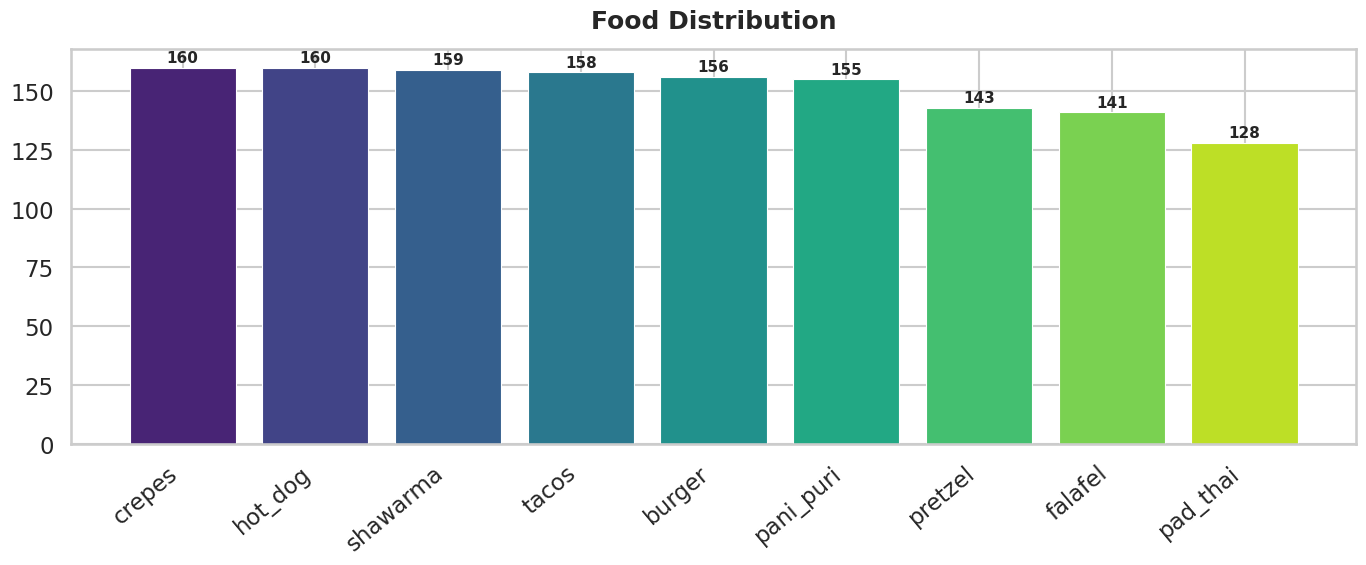

In [13]:
#Food Distribution

sns.set(style="whitegrid", context="talk")

counts = train_df["label"].value_counts()
colors = sns.color_palette("viridis", len(counts))

plt.figure(figsize=(14, 6))

bars = plt.bar(counts.index, counts.values, color=colors, linewidth=0.8)

plt.title("Food Distribution", fontweight="bold", pad=15)
plt.xticks(rotation=40, ha="right")
plt.bar_label(bars, label_type="edge", fontsize=11, fontweight="bold", padding=2)

plt.tight_layout()
plt.show()

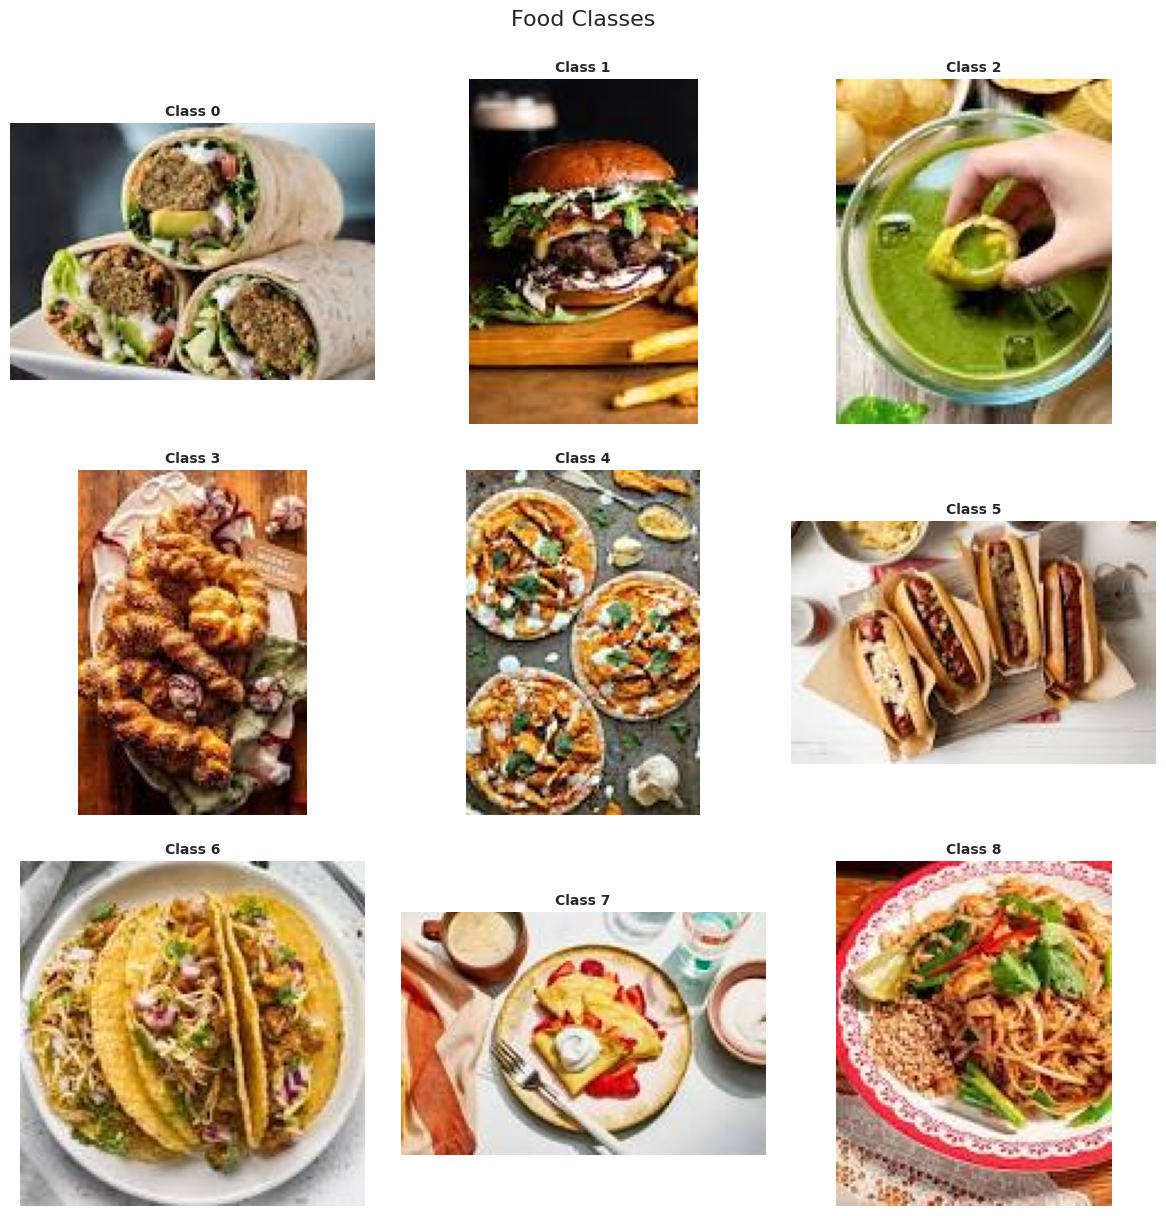

In [14]:
# Etiketleri alma
labels = train_df['label_encoded'].unique()

# Her işaret türünden ilk görseli alalım
images = []
for label in labels:
    img_paths = train_df[train_df['label_encoded'] == label]['img']
    if not img_paths.empty:
        img_path = img_paths.iloc[0]
        image = Image.open(img_path)
        images.append((image, label))

# 3x3 grid oluştur
plt.figure(figsize=(12, 12))

for i, (image, label) in enumerate(images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f'Class {label}', fontsize=10, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Food Classes', fontsize=16, y=1.02)
plt.show()

## Normalizing Images

In [15]:
#  Görüntü Yükleme ve Normalizasyon 
def load_image(img_path, img_size=(240, 240)):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    return img / 255.0

In [16]:
def load_dataset(df, img_size=(240, 240), has_label=True):
    images = []
    labels = []
    
    for row in df.itertuples():
        img = cv2.imread(row.img)
        if img is None:
            raise ValueError(f"Görsel okunamadı: {row.img}")
        img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), img_size) / 255.0
        images.append(img)
        
        if has_label:
            labels.append(row.label_encoded)
            
    images = np.array(images)
    
    if has_label:
        return images, np.array(labels)
    else:
        return images

In [17]:
print("Train verisi yükleniyor...")
x_train, y_train = load_dataset(train_df, has_label=True)
print(f"✅ Train verisi : {x_train.shape}")   
print(f"✅ Label sayısı : {len(y_train)}")    


print("\nTest verisi yükleniyor...")
x_test = load_dataset(test_df, has_label=False)
print(f"✅ Test verisi  : {x_test.shape}")    

Train verisi yükleniyor...
✅ Train verisi : (1360, 240, 240, 3)
✅ Label sayısı : 1360

Test verisi yükleniyor...
✅ Test verisi  : (764, 240, 240, 3)


## Train / Validation Split

In [18]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train          
)
print(f"Train: {x_train.shape}, Validation: {x_val.shape}")

Train: (1088, 240, 240, 3), Validation: (272, 240, 240, 3)


## CNN Modeling

In [19]:
model = Sequential([

    Input(shape=(240,240,3)),          

    # Block 1
    Conv2D(32, (3,3), padding="same", activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding="same", activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding="same", activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    # Block 4
    Conv2D(256, (3,3), padding="same", activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(9, activation='softmax')   # 9 sınıf var toplamda
])

I0000 00:00:1776886271.924240    2199 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [20]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 240, 240, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 240, 240, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    14,745,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,139,529 (57.75 MB)

 Trainable params: 15,138,057 (57.75 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [22]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [23]:
# Training
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


I0000 00:00:1776886280.064779    2262 service.cc:152] XLA service 0x7baea0002740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776886280.064977    2262 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776886280.920020    2262 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/34 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.1788 - loss: 4.2412

I0000 00:00:1776886291.707454    2262 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


34/34 ━━━━━━━━━━━━━━━━━━━━ 23s 202ms/step - accuracy: 0.2065 - loss: 3.7813 - val_accuracy: 0.1140 - val_loss: 17.2110 - learning_rate: 0.0010
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.3978 - loss: 3.0971 - val_accuracy: 0.1140 - val_loss: 13.8606 - learning_rate: 0.0010
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5401 - loss: 2.7202 - val_accuracy: 0.1250 - val_loss: 10.4373 - learning_rate: 0.0010
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.6523 - loss: 2.3594 - val_accuracy: 0.1434 - val_loss: 6.8444 - learning_rate: 0.0010
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8056 - loss: 2.0208 - val_accuracy: 0.1029 - val_loss: 6.1890 - learning_rate: 0.0010
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8425 - loss: 1.8638 - val_accuracy: 0.1029 - val_loss: 7.7887 - learning_rate: 0.0010
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8827 - loss: 1.7342 - val_accuracy:

## Saving the Model

In [24]:
model.save('street_food_cnn.h5')

In [25]:
model.save('street_food_cnn.keras')

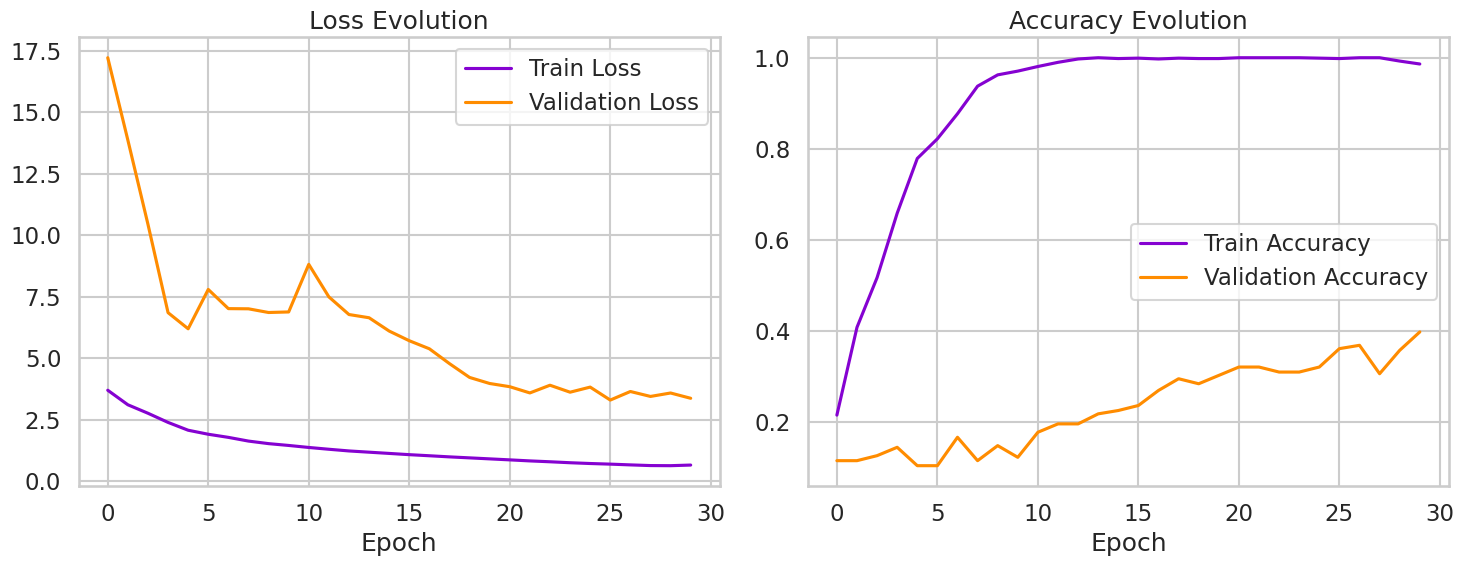

In [26]:
# Loss & Accuracy 
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss',      color='#8502d1')
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy',      color='#8502d1')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


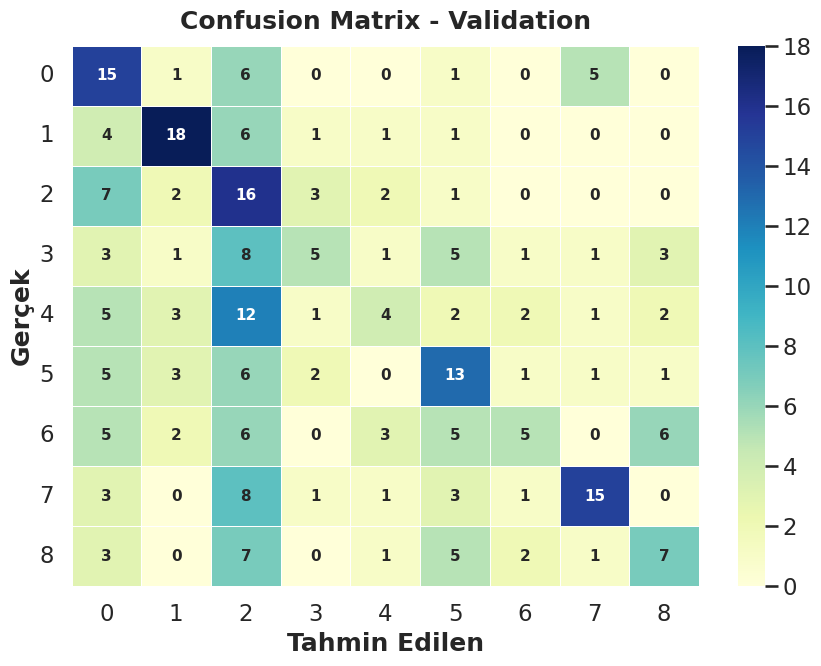

In [37]:
# Confusion Matrix - Validation
y_pred = np.argmax(model.predict(x_val), axis=1)
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    cmap="YlGnBu",
    annot=True,
    fmt="d",
    cbar=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title("Confusion Matrix - Validation", pad=12, weight="bold")
plt.xlabel("Tahmin Edilen", weight="bold")
plt.ylabel("Gerçek", weight="bold")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Predict on the Test

In [28]:
tahmin = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step


In [29]:
tahmin_classes = np.argmax(tahmin, axis=1)

class_names = {
    0: 'falafel',
    1: 'burger',
    2: 'pani_puri',
    3: 'pretzel',
    4: 'shawarma',
    5: 'hot_dog',
    6: 'tacos',
    7: 'crepes',
    8: 'pad_thai'
}

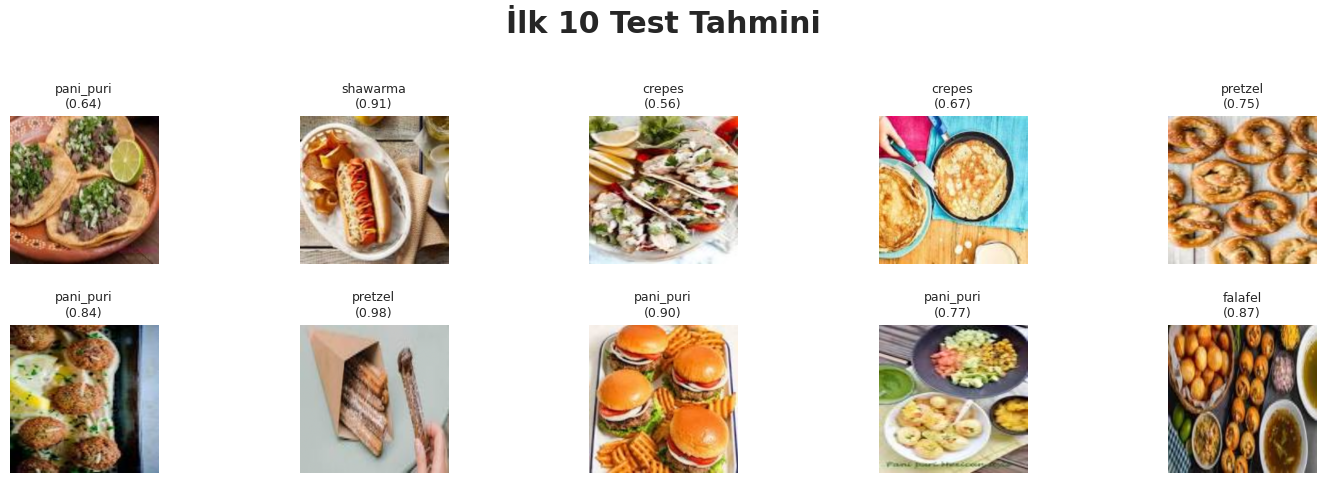

In [30]:
# İlk 10 test görseli
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])

    pred_class = tahmin_classes[i]
    confidence = tahmin[i][pred_class]

    plt.title(f"{class_names[pred_class]}\n({confidence:.2f})", fontsize=9)
    plt.axis('off')

plt.suptitle('İlk 10 Test Tahmini', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
tahmin_labels = [class_names[i] for i in tahmin_classes]

In [32]:
submission = pd.DataFrame({
    'image_id': test_df['img'].apply(os.path.basename),
    'label': tahmin_labels
})

In [33]:
submission = submission.sort_values('image_id').reset_index(drop=True)

In [34]:
submission.head()

,image_id,label
0,00de5019.jpg,pani_puri
1,013d2855.jpg,shawarma
2,02edbdf7.jpg,crepes
3,03139344.jpg,crepes
4,03413ef9.jpg,pretzel
